# The Complete ML Pipeline

### Table of contents
0. [Introduction](#0.-Introduction)
1. [Setup](#1.-Setup)
2. [Why the raw data can't go straight into a model](#2.-Why-the-raw-data-can't-go-straight-into-a-model)
3. [Building the full pipeline: preprocessor and model together](#3.-Building-the-full-pipeline:-preprocessor-and-model-together)
4. [Training and evaluating](#4.-Training-and-evaluating)
5. [Looking inside the fitted pipeline](#5.-Looking-inside-the-fitted-pipeline)
6. [Why one Test Set isn't enough for choosing between models](#6.-Why-one-Test-Set-isn't-enough-for-choosing-between-models)
7. [Cross-Validation](#7.-Cross-Validation)
8. [Comparing models with Cross-Validation](#8.-Comparing-models-with-Cross-Validation)
9. [Parameter vs Hyperparameter](#9.-Parameter-vs-Hyperparameter)
10. [GridSearchCV](#10.-GridSearchCV)
11. [RandomizedSearchCV](#11.-RandomizedSearchCV)
12. [Final Test Evaluation](#12.-Final-Test-Evaluation)
13. [Summary](#13.-Summary)
14. [Exercises](#14.-Exercises)

## 0. Introduction

Notebook 1 built a `ColumnTransformer`. This notebook attaches a model, trains and evaluates it, then goes further: how do we choose between several models, and tune each one's hyperparameters, without ever letting the test set influence that choice?

## 1. Setup

Same dataset as notebook 1, plus a couple of extra engineered columns for the exercises.

In [1]:
import numpy as np
import pandas as pd
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split

california = fetch_california_housing(as_frame=True)
housing = california.frame

rng = np.random.default_rng(42)
messy = housing.copy()
missing_idx = rng.choice(messy.index, size=200, replace=False)
messy.loc[missing_idx, "AveBedrms"] = np.nan
missing_idx_2 = rng.choice(messy.index, size=120, replace=False)
messy.loc[missing_idx_2, "AveRooms"] = np.nan

messy["coast_region"] = pd.cut(
    messy["Longitude"],
    bins=[-125, -121.22, -118.20, -114],
    labels=["Coastal", "Central", "Inland"],
)
messy["income_cat"] = pd.cut(
    messy["MedInc"],
    bins=[0, 2.5, 4.5, 7, np.inf],
    labels=["Low", "Medium", "High", "Very High"],
)
messy["bedrooms_ratio"] = messy["AveBedrms"] / messy["AveRooms"]
messy["rooms_per_person"] = messy["AveRooms"] / messy["AveOccup"]

X = messy.drop(columns="MedHouseVal")
y = messy["MedHouseVal"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

numeric_features = ["MedInc", "HouseAge", "AveRooms", "AveBedrms", "Population", "AveOccup", "Latitude", "Longitude"]
categorical_features = ["coast_region"]
X_train.shape, X_test.shape

((16512, 12), (4128, 12))

## 2. Why the raw data can't go straight into a model

In [2]:
from sklearn.linear_model import LinearRegression

naive_model = LinearRegression()
try:
    naive_model.fit(X_train[numeric_features + categorical_features], y_train)
except Exception as e:
    print(f"{type(e).__name__}:", e)

ValueError: Input contains NaN


`NaN` and a categorical column, both handled by notebook 1's pipeline.

## 3. Building the full pipeline: preprocessor and model together

In [3]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_features),
    ("categorical", categorical_pipeline, categorical_features),
])

model_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression()),
])
model_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, defau

## 4. Training and evaluating

One `fit`, on raw `X_train`.

In [4]:
model_pipeline.fit(X_train, y_train)

y_pred = model_pipeline.predict(X_test)
y_pred[:5]

array([0.78602189, 1.8090098 , 2.66456756, 2.92546619, 2.60313393])

In [5]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5
print(f"MAE:  {mae:.3f}")
print(f"RMSE: {rmse:.3f}")

MAE:  0.533
RMSE: 0.744


## 5. Looking inside the fitted pipeline

`named_steps` reaches down to the model's own coefficients.

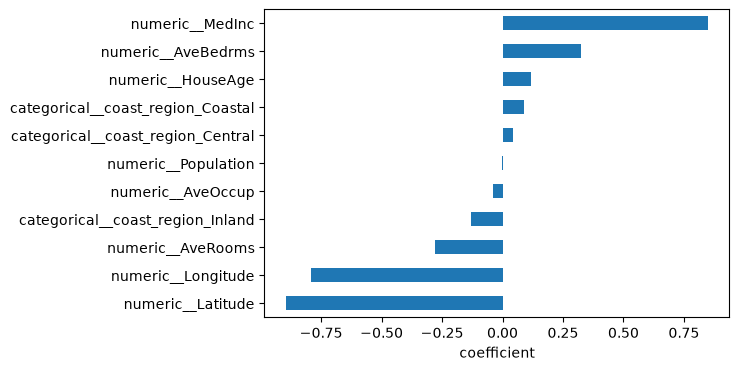

In [6]:
import matplotlib.pyplot as plt

fitted_preprocessor = model_pipeline.named_steps["preprocessor"]
fitted_model = model_pipeline.named_steps["model"]

pd.Series(
    fitted_model.coef_,
    index=fitted_preprocessor.get_feature_names_out(),
).sort_values().plot(kind="barh", figsize=(6, 4))
plt.xlabel("coefficient")
plt.show()

`MedInc` dominates, and the `coast_region` columns show up too, unusable as raw text.

## 6. Why one Test Set isn't enough for choosing between models

Three quick candidates, each scored once on `X_test`.

In [7]:
from sklearn.ensemble import RandomForestRegressor

candidates = {
    "Linear Regression": LinearRegression(),
    "Random Forest (100 trees)": RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    "Random Forest (300 trees)": RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1),
}

test_scores = {}
for name, model in candidates.items():
    pipe = Pipeline([("preprocessor", preprocessor), ("model", model)])
    pipe.fit(X_train, y_train)
    test_scores[name] = mean_squared_error(y_test, pipe.predict(X_test)) ** 0.5

test_scores

{'Linear Regression': 0.7441011210260271,
 'Random Forest (100 trees)': 0.505678222509813,
 'Random Forest (300 trees)': 0.5039132551991221}

Picking the smallest number here means `X_test` just influenced a modeling decision; it's no longer truly unseen for whatever comes next.

## 7. Cross-Validation

`cross_val_score` splits `X_train` into folds internally; `X_test` never appears in this cell.

In [8]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(model_pipeline, X_train, y_train, cv=5, scoring="neg_root_mean_squared_error")
-scores

array([0.72021391, 0.70728418, 0.71890307, 0.71050652, 0.73522149])

In [9]:
(-scores).mean(), (-scores).std()

(np.float64(0.7184258342122621), np.float64(0.009719783828943255))

The mean is the CV score; the spread across folds shows how much a single lucky or unlucky split could have misled us.

## 8. Comparing models with Cross-Validation

Same comparison as section 6, with CV scores instead of test scores.

In [10]:
candidates = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1),
}

cv_results = {}
for name, model in candidates.items():
    pipe = Pipeline([("preprocessor", preprocessor), ("model", model)])
    fold_scores = cross_val_score(pipe, X_train, y_train, cv=5, scoring="neg_root_mean_squared_error")
    cv_results[name] = -fold_scores.mean()

cv_results

{'Linear Regression': np.float64(0.7184258342122621),
 'Random Forest': np.float64(0.5090522939652236)}

`X_test` still hasn't been touched since section 6; the choice between models can happen entirely on `X_train`.

## 9. Parameter vs Hyperparameter

`fitted_model.coef_` (section 5) is a Parameter, learned from data. `n_estimators=300` above is a Hyperparameter, chosen before training.

In [11]:
RandomForestRegressor().get_params()

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'criterion': 'squared_error',
 'max_depth': None,
 'max_features': 1.0,
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 100,
 'n_jobs': None,
 'oob_score': False,
 'random_state': None,
 'verbose': 0,
 'warm_start': False}

Everything in that dictionary is a Hyperparameter; none of it is learned from data.

## 10. GridSearchCV

`model__n_estimators` reaches into the pipeline's `model` step by name; that's how a search tunes hyperparameters that live inside a `Pipeline`.

In [12]:
from sklearn.model_selection import GridSearchCV

forest_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(random_state=42, n_jobs=-1)),
])

param_grid = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [None, 10, 20],
}

grid_search = GridSearchCV(
    forest_pipeline, param_grid, cv=5, scoring="neg_root_mean_squared_error", n_jobs=-1
)
grid_search.fit(X_train, y_train)
grid_search.best_params_

{'model__max_depth': None, 'model__n_estimators': 300}

In [13]:
-grid_search.best_score_

np.float64(0.5090522939652234)

`best_params_`, `best_score_`, and `best_estimator_` all come from `X_train` alone, 9 combinations x 5 folds, `X_test` still untouched.

## 11. RandomizedSearchCV

A wider search space this time, 7 x 6 = 42 combinations, sampling only 10 of them.

In [14]:
from sklearn.model_selection import RandomizedSearchCV

param_distributions = {
    "model__n_estimators": [50, 100, 150, 200, 250, 300, 400],
    "model__max_depth": [None, 5, 10, 15, 20, 25],
}

random_search = RandomizedSearchCV(
    forest_pipeline, param_distributions, n_iter=10, cv=5,
    scoring="neg_root_mean_squared_error", random_state=42, n_jobs=-1,
)
random_search.fit(X_train, y_train)
random_search.best_params_, -random_search.best_score_

({'model__n_estimators': 400, 'model__max_depth': None},
 np.float64(0.5083324298551172))

10 trainings x 5 folds instead of 42 x 5; the tradeoff is no guarantee of finding the single best combination in the grid.

## 12. Final Test Evaluation

`X_test` touched exactly once, here, after every model and hyperparameter choice was already locked in by Cross-Validation.

In [15]:
best_model = grid_search.best_estimator_

y_pred_final = best_model.predict(X_test)

mae_final = mean_absolute_error(y_test, y_pred_final)
rmse_final = mean_squared_error(y_test, y_pred_final) ** 0.5
print(f"MAE:  {mae_final:.3f}")
print(f"RMSE: {rmse_final:.3f}")

MAE:  0.327
RMSE: 0.504


In [16]:
print(f"Baseline (Linear Regression) test RMSE: {rmse:.3f}")
print(f"Tuned Random Forest test RMSE:          {rmse_final:.3f}")

Baseline (Linear Regression) test RMSE: 0.744
Tuned Random Forest test RMSE:          0.504


## 13. Summary

- One test-set score per model (section 6) quietly turns the test set into a selection tool; Cross-Validation (section 7) avoids that by scoring on `X_train` alone.
- Comparing models means comparing CV scores (section 8), not test scores.
- A Parameter is learned during training; a Hyperparameter is chosen before it (section 9).
- `GridSearchCV` tries every combination in `param_grid`; `RandomizedSearchCV` samples a fixed number of combinations, better when the grid is large.
- Both searches use `model__<name>` to reach inside a `Pipeline`, so the whole preprocessor gets refit correctly on every fold, automatically.
- `X_test` is touched exactly once, at the very end, only to report the final number.

## 14. Exercises

1. Add a third candidate to section 8's comparison (e.g. `Ridge` or `GradientBoostingRegressor`) and rank all three by CV score.
2. Widen section 10's `param_grid` with one more value per hyperparameter; does `best_params_` change?
3. Re-run section 11 with `n_iter=20` instead of 10; how close does `best_score_` get to section 10's grid result?
4. Build a small table with columns Model, CV RMSE, Test RMSE for every model trained in this notebook.